In [1]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import json
import scipy.optimize as curve_fit
from scipy.interpolate import PchipInterpolator
from scipy.interpolate import make_interp_spline

In [2]:
current_directory = Path.cwd().parent
discharge_directory = Path.joinpath(current_directory, "Data Start Point")

compiled_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled (with SoC).csv")
points_of_interest_file_name = Path.joinpath(discharge_directory, "points_of_interest.json")
RC_values_file_name = Path.joinpath(discharge_directory, "RC_values.csv")
ocv_soc_dict_file_name = Path.joinpath(discharge_directory, "ocv_soc_dict.csv")
battery_state_file_name = Path.joinpath(discharge_directory, "battery_state.csv")

In [3]:
points_of_interest = json.load(open(points_of_interest_file_name, 'r'))

In [4]:
compiled_df = pd.read_csv(compiled_file_name)

In [5]:
before_open = points_of_interest['before_open']
before_close = points_of_interest['before_close']

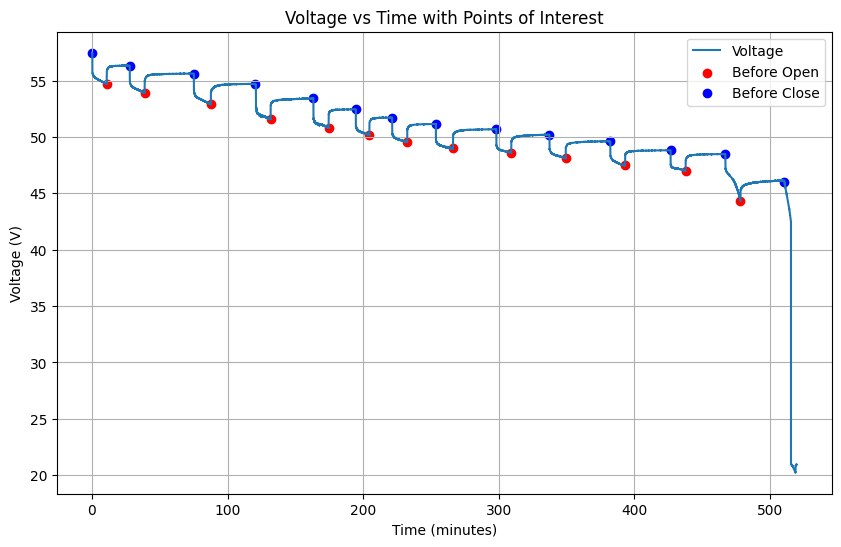

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(compiled_df['Translated Time (minutes)'], compiled_df['Calibrated Voltage'], label='Voltage')
plt.scatter(before_open['time'], before_open['voltage'], color='red', label='Before Open')
plt.scatter(before_close['time'], before_close['voltage'], color='blue', label='Before Close')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time with Points of Interest')
plt.legend()
plt.grid()
plt.show()

In [ ]:
if before_close['time'][0] < before_open['time'][0]:
    before_close['time'] = before_close['time'][1:]
    before_close['voltage'] = before_close['voltage'][1:]
    before_close['index'] = before_close['index'][1:]
    print("Dropped first point from before_close.")

Dropped first point from before_close.


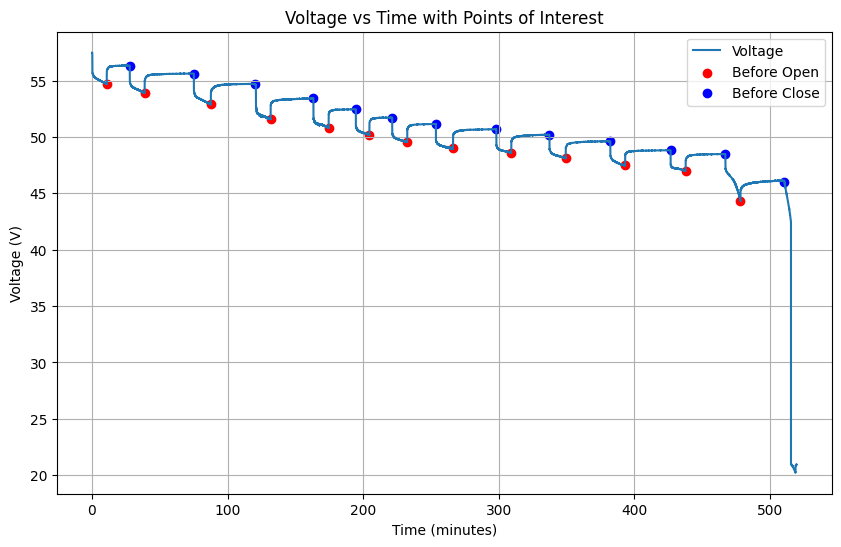

In [9]:
# Make sure there are pairs of before open and before close for each resting period

plt.figure(figsize=(10, 6))
plt.plot(compiled_df['Translated Time (minutes)'], compiled_df['Calibrated Voltage'], label='Voltage')
plt.scatter(before_open['time'], before_open['voltage'], color='red', label='Before Open')
plt.scatter(before_close['time'], before_close['voltage'], color='blue', label='Before Close')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time with Points of Interest')
plt.legend()
plt.grid()
plt.show()

In [11]:
# V(t) = OCV - A1 * e^(-t / tau1) - A2 * e^(-t / tau2)
def two_rc_model(t, OCV, A1, tau1, A2, tau2):
    return OCV - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

def curve_fit_bound(ocv, v_0_before_switch):
    # [ocv, A1, tau1, A2, tau2]
    lower = [
        ocv - 0.5,  # Cannot be less than 500mV below OCV
        0.001, 1,   # Must be positive
        0.001, 1
        ]
    
    total_swing = ocv - v_0_before_switch

    # Upper bound time constant is set arbitrarily
    # but tau2 > tau1
    upper = [
        ocv + 0.5,  # Cannot be more than 500mV above OCV
        total_swing, 150,   # Fast RC
        total_swing, 2000   # slow RC
        ]
    return (lower, upper)

def initial_guess(ocv, v_0_before_switch):
    total_swing = ocv - v_0_before_switch
    A1_guess = total_swing * 0.8  # Initial guess for A1 based on voltage drop
    A2_guess = total_swing * 0.4  # Assume the second RC contributes less
    tau1_guess = 50  # Fast RC time constant guess
    tau2_guess = 500  # Slow RC time constant guess

    return [ocv, A1_guess, tau1_guess, A2_guess, tau2_guess]

In [12]:
def extract_last_stable_current(compiled_df, start_index):
    STEP_SIZE = 20
    threshold = 0.5
    df = compiled_df[max(0, start_index - STEP_SIZE): start_index]  # Look back up to 20 rows
    median_current = df['Calibrated Current 1'].median()
    
    index_at_stable = start_index
    total = []
    
    for i in range(start_index, max(0, start_index - STEP_SIZE), -1):
        diff = abs((compiled_df['Calibrated Current 1'][i] + compiled_df['Calibrated Current 2'][i]) / 2 - median_current)
        if diff < threshold:
            total.append((compiled_df['Calibrated Current 1'][i]  + compiled_df['Calibrated Current 2'][i]) / 2)
            index_at_stable = i if index_at_stable == start_index else index_at_stable
            
    return sum(total) / len(total) if total else 0, index_at_stable 

In [13]:
fitted_params_list = {
    "SoC": [],
    "OCV": [],
    "r0": [],
    "A1": [],
    "tau1": [],
    "r1": [],
    "c1": [],
    "A2": [],
    "tau2": [],
    "r2": [],
    "c2": []
}

if len(before_open['time']) != len(before_close['time']):
    print("Warning: before_open and before_close have different lengths.")
else:
    for i in range(len(before_open['time'])):
        rest_interval = (before_open['index'][i], before_close['index'][i])

        # Start fitting once the current reading is 0
        found_zero_current = False
        for j in range(rest_interval[0], rest_interval[1]):
            if compiled_df['Calibrated Current 1'][j] < 1:
                found_zero_current = True
                break
        if not found_zero_current:
            print(f"Warning: No zero current point found between indices {rest_interval[0]} and {rest_interval[1]}. Skipping this interval.")
            continue
        
        start_index = j
        
        df_interval = compiled_df.iloc[start_index:rest_interval[1]]
        time_data_s = (df_interval['Translated Time (minutes)'] - df_interval['Translated Time (minutes)'].iloc[0]) * 60  # Reset time to start at 0
        voltage_data = df_interval['Calibrated Voltage']
        ocv = before_close['voltage'][i]
        before_open_voltage = before_open['voltage'][i]
        params, cov = curve_fit.curve_fit(two_rc_model, time_data_s, voltage_data, 
                                          p0=initial_guess(ocv, before_open_voltage), 
                                          bounds=curve_fit_bound(ocv, before_open_voltage))
        
        OCV_fit, A1_fit, tau1_fit, A2_fit, tau2_fit = params
        print(f"Interval {i}: OCV={OCV_fit:.3f} V, A1={A1_fit:.3f} V, tau1={tau1_fit:.2f} s, A2={A2_fit:.3f} V, tau2={tau2_fit:.2f} s")
        print(f"Function: V(t) = {OCV_fit:.3f} - {A1_fit:.3f} * np.exp(-t / {tau1_fit:.2f}) - {A2_fit:.3f} * np.exp(-t / {tau2_fit:.2f})")
        
        # Fitting evaluation
        v_fitted = two_rc_model(time_data_s, *params)
        residuals = voltage_data - v_fitted
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((voltage_data - np.mean(voltage_data))**2)
        r_squared = 1 - (ss_res / ss_tot)
        print(f"R-squared: {r_squared:.4f}")
        
        # Extract RC values
        I_before, stable_index = extract_last_stable_current(compiled_df, start_index)

        R1 = A1_fit / I_before  if I_before != 0 else np.inf
        C1 = tau1_fit / R1      if R1 != np.inf else np.inf
        R2 = A2_fit / I_before  if I_before != 0 else np.inf
        C2 = tau2_fit / R2      if R2 != np.inf else np.inf
        
        V_after = two_rc_model(0, *params)  # Voltage at t=0
        V_before = compiled_df['Calibrated Voltage'][stable_index-10:stable_index].mean()  # Average voltage before switch
        R0 = abs(V_before - V_after) / I_before if I_before != 0 else np.inf
        
        # Store fitted parameters
        fitted_params_list["OCV"].append(OCV_fit)
        fitted_params_list["r0"].append(R0)
        fitted_params_list["A1"].append(A1_fit)
        fitted_params_list["r1"].append(R1)
        fitted_params_list["c1"].append(C1)
        fitted_params_list["A2"].append(A2_fit)
        fitted_params_list["r2"].append(R2)
        fitted_params_list["c2"].append(C2)
        fitted_params_list["SoC"].append(compiled_df['SoC'].iloc[stable_index])
        fitted_params_list["tau1"].append(tau1_fit)
        fitted_params_list["tau2"].append(tau2_fit)
        
        print(f"RC values: R0={R0:.5f} Ohm, R1={R1:.5f} Ohm, C1={C1:.5f} F, R2={R2:.5f} Ohm, C2={C2:.5f} F\n")     
        

Interval 0: OCV=56.333 V, A1=0.388 V, tau1=43.12 s, A2=0.152 V, tau2=266.07 s
Function: V(t) = 56.333 - 0.388 * np.exp(-t / 43.12) - 0.152 * np.exp(-t / 266.07)
R-squared: 0.9978
RC values: R0=0.03895 Ohm, R1=0.01384 Ohm, C1=3115.27816 F, R2=0.00544 Ohm, C2=48907.83858 F

Interval 1: OCV=55.627 V, A1=0.508 V, tau1=53.84 s, A2=0.180 V, tau2=643.19 s
Function: V(t) = 55.627 - 0.508 * np.exp(-t / 53.84) - 0.180 * np.exp(-t / 643.19)
R-squared: 0.9977
RC values: R0=0.03882 Ohm, R1=0.01890 Ohm, C1=2849.27046 F, R2=0.00672 Ohm, C2=95774.31669 F

Interval 2: OCV=54.703 V, A1=0.434 V, tau1=60.82 s, A2=0.363 V, tau2=356.81 s
Function: V(t) = 54.703 - 0.434 * np.exp(-t / 60.82) - 0.363 * np.exp(-t / 356.81)
R-squared: 0.9981
RC values: R0=0.03802 Ohm, R1=0.01632 Ohm, C1=3727.26226 F, R2=0.01363 Ohm, C2=26175.67326 F

Interval 3: OCV=53.461 V, A1=0.385 V, tau1=59.46 s, A2=0.265 V, tau2=1050.83 s
Function: V(t) = 53.461 - 0.385 * np.exp(-t / 59.46) - 0.265 * np.exp(-t / 1050.83)
R-squared: 0.9981


In [14]:
print(json.dumps(fitted_params_list, indent=4))

{
    "SoC": [
        92.2537241944343,
        84.89487179900198,
        76.42675804543954,
        68.81046299184594,
        61.37326504716308,
        54.9432658620082,
        47.98304211539591,
        40.1304755280176,
        32.720997281204525,
        25.11763124091369,
        18.13627023812721,
        11.124674332648407,
        4.270320484818386
    ],
    "OCV": [
        56.333420767664656,
        55.62684025193965,
        54.702520250073,
        53.460829060216696,
        52.456421505774365,
        51.72572162530646,
        51.14778466151965,
        50.68430036209365,
        50.210865819747056,
        49.62566988755915,
        48.825597508260714,
        48.48627447020647,
        46.17553394475274
    ],
    "r0": [
        0.03895210901898927,
        0.03882245746590915,
        0.03802369856887615,
        0.04531627919693773,
        0.04432379449778911,
        0.04142647676428745,
        0.0426937749700584,
        0.044869242829092874,
        0.03

In [15]:
def r_squared(actual_x, actual_y, model, *params):
    predicted_y = model(actual_x, *params)
    residuals = actual_y - predicted_y
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((actual_y - np.mean(actual_y))**2)
    return 1 - (ss_res / ss_tot)

In [16]:
r0_cleaned = []
r0_soc = []
r1_cleaned = []
r1_soc = []
r2_cleaned = []
r2_soc = []

r0_index_to_drop = []
r1_index_to_drop = []
r2_index_to_drop = []
for i in range(len(fitted_params_list["SoC"])):
    if i not in r0_index_to_drop:
        r0_cleaned.append(fitted_params_list["r0"][i])
        r0_soc.append(fitted_params_list["SoC"][i])
    
    if i not in r1_index_to_drop:
        r1_cleaned.append(fitted_params_list["r1"][i])
        r1_soc.append(fitted_params_list["SoC"][i])

    if i not in r2_index_to_drop:
        r2_cleaned.append(fitted_params_list["r2"][i])
        r2_soc.append(fitted_params_list["SoC"][i])

R-squared for R0 fit: 0.6838
R-squared for R1 fit: 0.4851
R-squared for R2 fit: 0.4662
R0 fit parameters: [ 3.64925625e-09 -5.57584611e-08 -9.67061963e-06  1.18991975e-04
  4.34120036e-02]
R1 fit parameters: [-1.34644445e-09 -4.96893480e-08  4.05897853e-06  7.49865420e-05
  1.28647591e-02]
R2 fit parameters: [ 1.50555072e-09 -1.16620284e-07 -1.43638649e-06  1.10684876e-04
  8.16228146e-03]


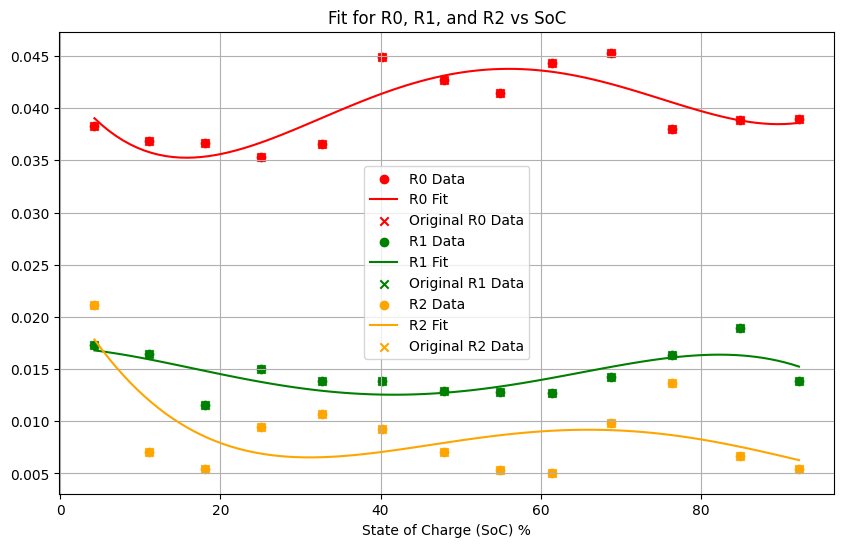

In [17]:
CENTER = 50 # Shift center of graph at 50% SoC to origin
r_model = lambda x, a, b, c, d, e: a * (x - CENTER)**4 + b * (x - CENTER)**3 + c * (x - CENTER)**2 + d * (x - CENTER) + e

r0_params, _ = curve_fit.curve_fit(r_model, r0_soc, r0_cleaned)
r1_params, _ = curve_fit.curve_fit(r_model, r1_soc, r1_cleaned)
r2_params, _ = curve_fit.curve_fit(r_model, r2_soc, r2_cleaned)
print(f"R-squared for R0 fit: {r_squared(np.array(r0_soc), np.array(r0_cleaned), r_model, *r0_params):.4f}")
print(f"R-squared for R1 fit: {r_squared(np.array(r1_soc), np.array(r1_cleaned), r_model, *r1_params):.4f}")
print(f"R-squared for R2 fit: {r_squared(np.array(r2_soc), np.array(r2_cleaned), r_model, *r2_params):.4f}")
print(f"R0 fit parameters: {r0_params}")
print(f"R1 fit parameters: {r1_params}")
print(f"R2 fit parameters: {r2_params}")
x_fit_r = np.linspace(min(fitted_params_list["SoC"]), max(fitted_params_list["SoC"]), 100)

plt.figure(figsize=(10, 6))
plt.scatter(r0_soc, r0_cleaned, label='R0 Data', color='red')
plt.plot(x_fit_r, r_model(x_fit_r, *r0_params), label='R0 Fit', color='red')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["r0"], label='Original R0 Data', color='red', marker='x')

plt.scatter(r1_soc, r1_cleaned, label='R1 Data', color='green')
plt.plot(x_fit_r, r_model(x_fit_r, *r1_params), label='R1 Fit', color='green')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["r1"], label='Original R1 Data', color='green', marker='x')

plt.scatter(r2_soc, r2_cleaned, label='R2 Data', color='orange')
plt.plot(x_fit_r, r_model(x_fit_r, *r2_params), label='R2 Fit', color='orange')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["r2"], label='Original R2 Data', color='orange', marker='x')

plt.title('Fit for R0, R1, and R2 vs SoC')
plt.xlabel('State of Charge (SoC) %')
plt.legend()
plt.grid()
plt.show()

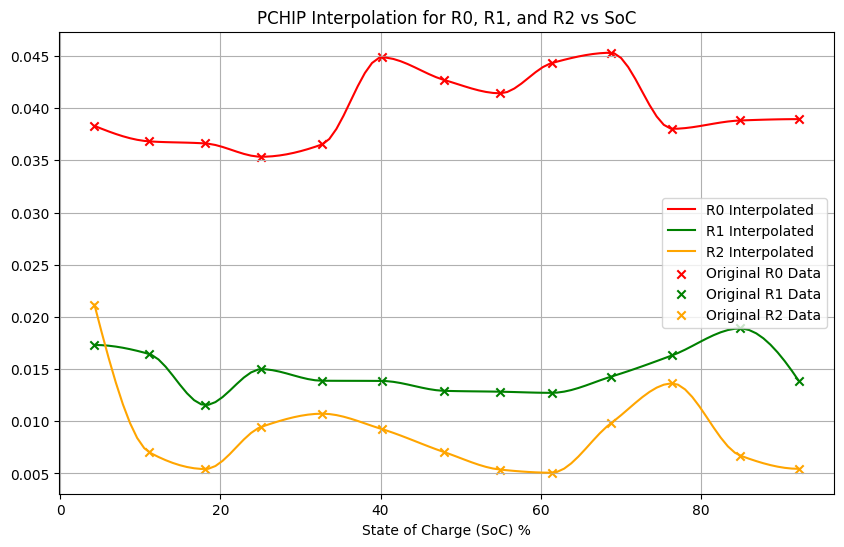

In [18]:
r0_interpolator = PchipInterpolator(np.flip(r0_soc), np.flip(r0_cleaned))
r1_interpolator = PchipInterpolator(np.flip(r1_soc), np.flip(r1_cleaned))
r2_interpolator = PchipInterpolator(np.flip(r2_soc), np.flip(r2_cleaned))

soc_range = np.linspace(min(fitted_params_list["SoC"]), max(fitted_params_list["SoC"]), 100)

r0_smooth = r0_interpolator(soc_range)
r1_smooth = r1_interpolator(soc_range)
r2_smooth = r2_interpolator(soc_range)

plt.figure(figsize=(10, 6))
plt.plot(soc_range, r0_smooth, label='R0 Interpolated', color='red')
plt.plot(soc_range, r1_smooth, label='R1 Interpolated', color='green')
plt.plot(soc_range, r2_smooth, label='R2 Interpolated', color='orange')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["r0"], label='Original R0 Data', color='red', marker='x')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["r1"], label='Original R1 Data', color='green', marker='x')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["r2"], label='Original R2 Data', color='orange', marker='x')
plt.title('PCHIP Interpolation for R0, R1, and R2 vs SoC')
plt.xlabel('State of Charge (SoC) %')   
plt.legend()
plt.grid()
plt.show()

Tau1 quartic fit parameters: [ 3.13050458e-06 -1.93624128e-03  5.38618625e+01]
R-squared for Tau1 fit: 0.1515 (original data R-squared: 0.0582)


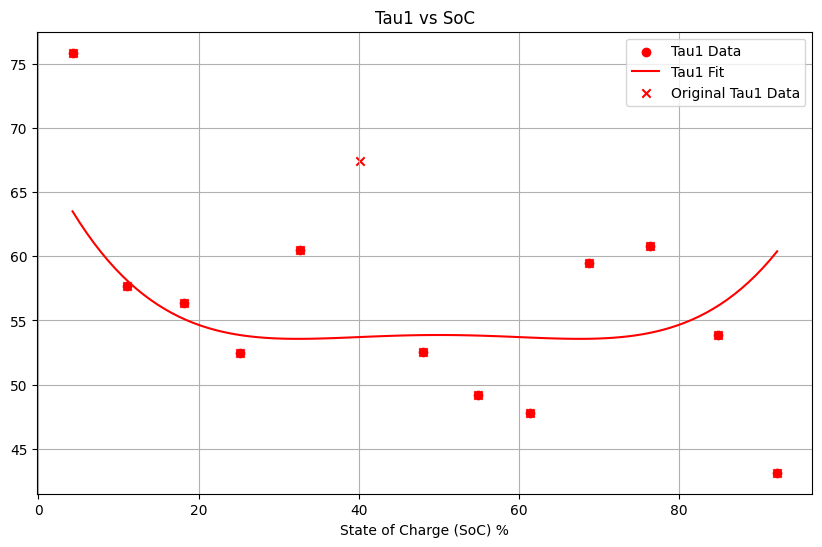

In [19]:
tau_1_cleaned = []
tau_1_soc = []

tau_1_index_to_drop = [7]

for i in range(len(fitted_params_list["SoC"])):
    if i not in tau_1_index_to_drop:
        tau_1_cleaned.append(fitted_params_list["tau1"][i])
        tau_1_soc.append(fitted_params_list["SoC"][i])
        
t_model = lambda x, a, b, c: a * (x - CENTER)**4 + b * (x - CENTER)**2 + c
tau_1_params, _ = curve_fit.curve_fit(t_model, tau_1_soc, tau_1_cleaned)
print(f"Tau1 quartic fit parameters: {tau_1_params}")

ori_r_squared = r_squared(np.array(fitted_params_list["SoC"]), np.array(fitted_params_list["tau1"]), t_model, *tau_1_params)
filtered_r_squared = r_squared(np.array(tau_1_soc), np.array(tau_1_cleaned), t_model, *tau_1_params)
print(f"R-squared for Tau1 fit: {filtered_r_squared:.4f} (original data R-squared: {ori_r_squared:.4f})")
x_linespace = np.linspace(min(fitted_params_list["SoC"]), max(fitted_params_list["SoC"]), 100)

plt.figure(figsize=(10, 6))
plt.scatter(tau_1_soc, tau_1_cleaned, label='Tau1 Data', color='red')
plt.plot(x_linespace, t_model(x_linespace, *tau_1_params), label='Tau1 Fit', color='red')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["tau1"], color='red', marker='x', label='Original Tau1 Data')

plt.title('Tau1 vs SoC')
plt.xlabel('State of Charge (SoC) %')
plt.legend()
plt.grid()
plt.show()


Tau2 quadratic fit parameters: [-7.97160506e-05  2.56472641e-01  3.71271604e+02]
R-squared for Tau2 fit: 0.2238
R-squared for original Tau2 data: 0.0174


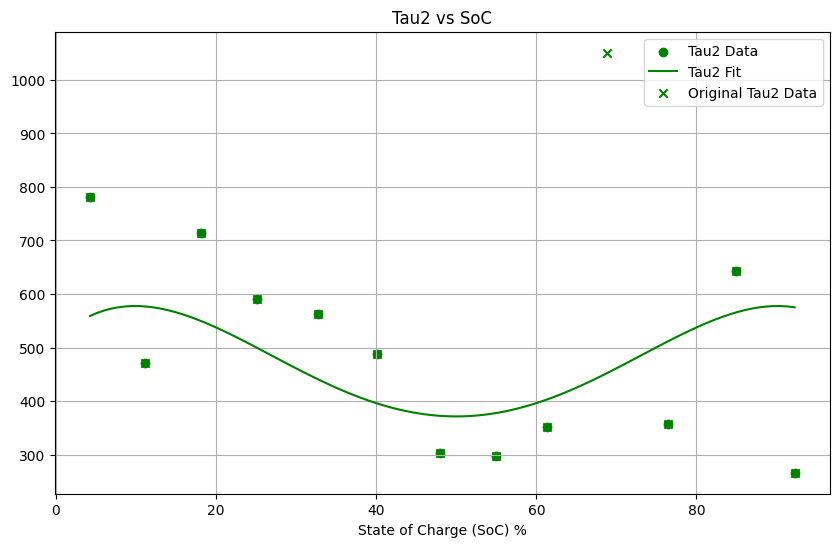

In [20]:
tau_2_cleaned = []
tau_2_soc = []

tau_2_index_to_drop = [3]

for i in range(len(fitted_params_list["SoC"])):   
    if i not in tau_2_index_to_drop:
        tau_2_cleaned.append(fitted_params_list["tau2"][i])
        tau_2_soc.append(fitted_params_list["SoC"][i])

t_model = lambda x, a, b, c: a * (x - CENTER)**4 + b * (x - CENTER)**2 + c
tau_2_params, _ = curve_fit.curve_fit(t_model, tau_2_soc, tau_2_cleaned)
print(f"Tau2 quadratic fit parameters: {tau_2_params}")

print(f"R-squared for Tau2 fit: {r_squared(np.array(tau_2_soc), np.array(tau_2_cleaned), t_model, *tau_2_params):.4f}")
print(f"R-squared for original Tau2 data: {r_squared(np.array(fitted_params_list["SoC"]), np.array(fitted_params_list['tau2']), t_model, *tau_2_params):.4f}")
x_linespace = np.linspace(min(fitted_params_list["SoC"]), max(fitted_params_list["SoC"]), 100)

plt.figure(figsize=(10, 6))

plt.scatter(tau_2_soc, tau_2_cleaned, label='Tau2 Data', color='green')
plt.plot(x_linespace, t_model(x_linespace, *tau_2_params), label='Tau2 Fit', color='green')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["tau2"], color='green', marker='x', label='Original Tau2 Data')
plt.title('Tau2 vs SoC')
plt.xlabel('State of Charge (SoC) %')
plt.legend()
plt.grid()
plt.show()


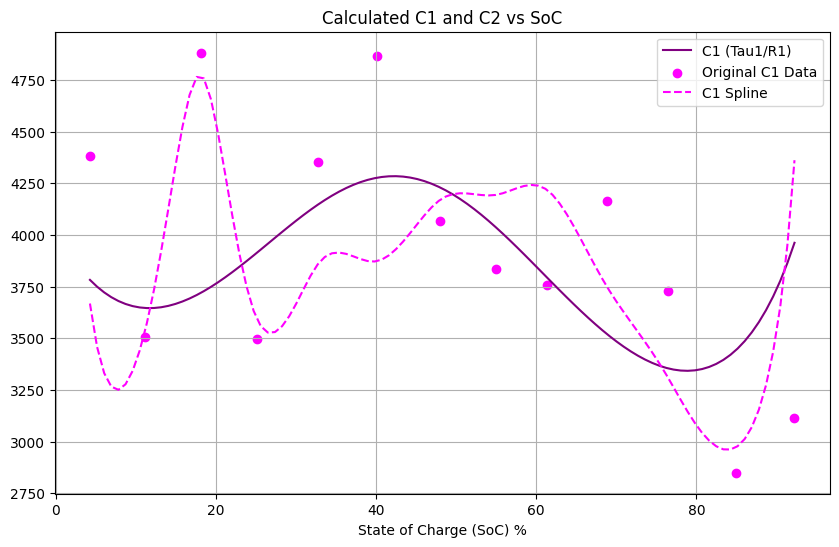

In [21]:
soc_range = np.linspace(min(fitted_params_list["SoC"]), max(fitted_params_list["SoC"]), 100)

tau_1_smooth = t_model(soc_range, *tau_1_params)
r1_smooth = r_model(soc_range, *r1_params)

r1_spline = make_interp_spline(np.flip(r1_soc), np.flip(r1_cleaned), k=3)
r1_spline_smooth = r1_spline(soc_range)

c1 = tau_1_smooth / r1_smooth
c1_spline = tau_1_smooth / r1_spline_smooth

plt.figure(figsize=(10, 6))
plt.plot(soc_range, c1, label='C1 (Tau1/R1)', color='purple')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["c1"], label='Original C1 Data', color='magenta', marker='o')
plt.plot(soc_range, c1_spline, label='C1 Spline', color='magenta', linestyle='--')
plt.title('Calculated C1 and C2 vs SoC')    
plt.xlabel('State of Charge (SoC) %')
plt.legend()
plt.grid()
plt.show()

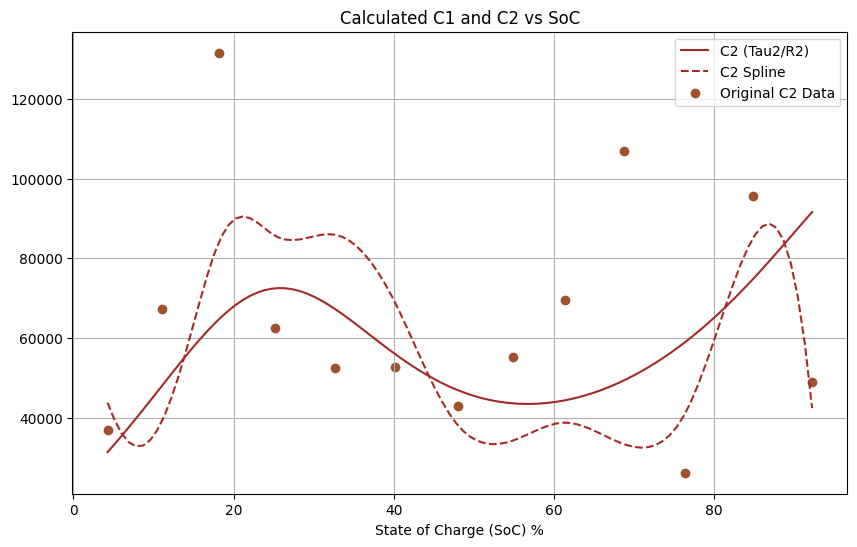

In [22]:
soc_range = np.linspace(min(fitted_params_list["SoC"]), max(fitted_params_list["SoC"]), 100)

tau_2_smooth = t_model(soc_range, *tau_2_params)
r2_smooth = r_model(soc_range, *r2_params)

tau_2_spline = make_interp_spline(np.flip(tau_2_soc), np.flip(tau_2_cleaned), k=3)
tau_2_spline_smooth = tau_2_spline(soc_range)
c2 = tau_2_smooth / r2_smooth

plt.figure(figsize=(10, 6))
plt.plot(soc_range, c2, label='C2 (Tau2/R2)', color='brown')
plt.plot(soc_range, tau_2_spline_smooth / r2_smooth, label='C2 Spline', color='brown', linestyle='--')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["c2"], label='Original C2 Data', color='sienna', marker='o')
plt.title('Calculated C1 and C2 vs SoC')    
plt.xlabel('State of Charge (SoC) %')
plt.legend()
plt.grid()
plt.show()

C1 quadratic fit parameters: [-3.47879456e-01 -1.33298356e+01  4.15438003e+03]
R-squared for C1 fit (Cleaned Data): 0.4641
R-squared for C1 fit (Original Data): 0.4641


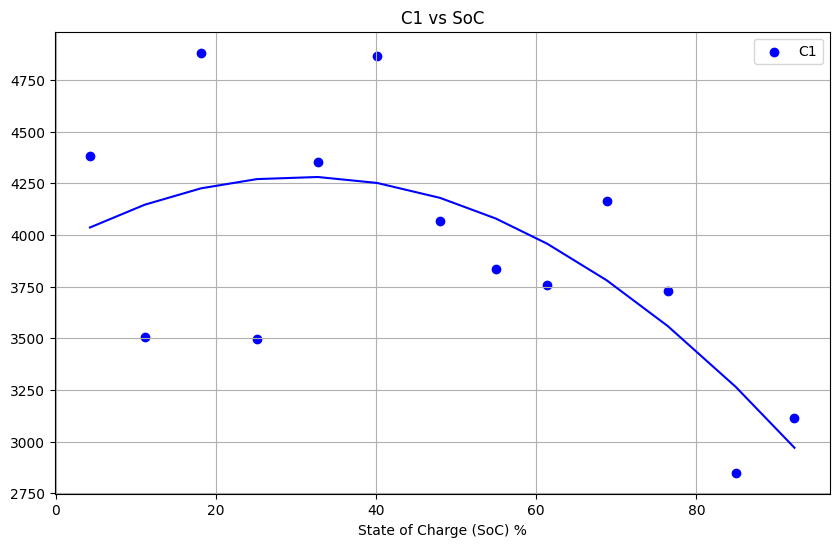

In [23]:
c1_cleaned = []
c1_soc = []

c1_index_to_drop = []
for i in range(len(fitted_params_list["SoC"])):
    if i not in c1_index_to_drop:
        c1_cleaned.append(fitted_params_list["c1"][i])
        c1_soc.append(fitted_params_list["SoC"][i])
        
CENTER = 50 # Shift center of graph at 50% SoC to origin
c_model = lambda x, a, b, c: a * (x - CENTER)**2 + b * (x - CENTER)**1 + c

c1_params, _ = curve_fit.curve_fit(c_model, c1_soc, c1_cleaned)
print(f"C1 quadratic fit parameters: {c1_params}")
print(f"R-squared for C1 fit (Cleaned Data): {r_squared(np.array(c1_soc), np.array(c1_cleaned), c_model, *c1_params):.4f}")
print(f"R-squared for C1 fit (Original Data): {r_squared(np.array(fitted_params_list["SoC"]), np.array(fitted_params_list['c1']), c_model, *c1_params):.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(c1_soc, c1_cleaned, label='C1 Data', color='blue')
plt.plot(np.array(c1_soc), c_model(np.array(c1_soc), *c1_params), label='C1 Fit', color='blue')
plt.title('C1 vs SoC')
plt.xlabel('State of Charge (SoC) %')
plt.legend(['C1'])
plt.grid()
plt.show()


C2 quartic fit parameters: [-2.18422867e+00  1.96524144e+02  6.13846374e+04]
R-squared for C2 fit (filtered): 0.0678
R-squared for C2 fit (original): -0.0976


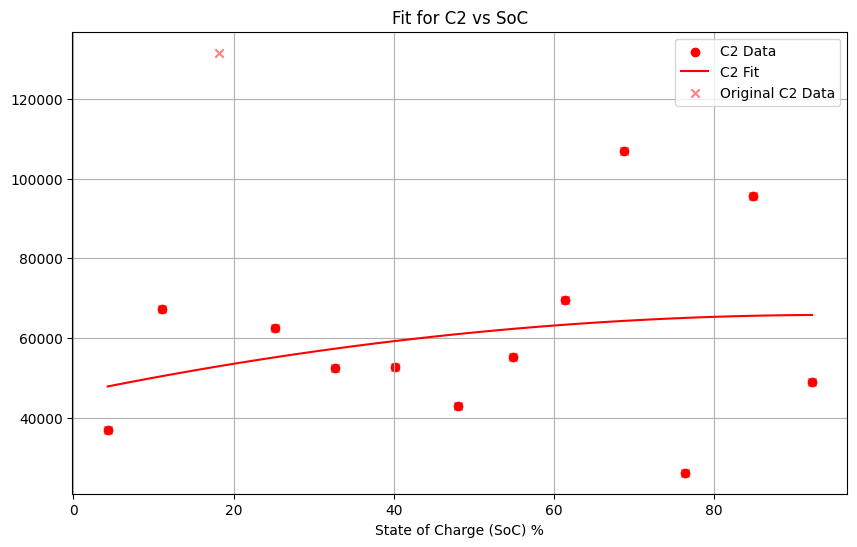

In [24]:
c2_cleaned = []
c2_soc = []

c2_index_to_drop = [10]
for i in range(len(fitted_params_list["c2"])):
    if i not in c2_index_to_drop:
        c2_cleaned.append(fitted_params_list["c2"][i])
        c2_soc.append(fitted_params_list["SoC"][i])

c2_params, _ = curve_fit.curve_fit(c_model, c2_soc, c2_cleaned)
print(f"C2 quartic fit parameters: {c2_params}")
print(f"R-squared for C2 fit (filtered): {r_squared(np.array(c2_soc), np.array(c2_cleaned), c_model, *c2_params):.4f}")
print(f"R-squared for C2 fit (original): {r_squared(np.array(fitted_params_list["SoC"]), np.array(fitted_params_list['c2']), c_model, *c2_params):.4f}")
x_fit_c = np.linspace(min(c2_soc), max(c2_soc), 100)

plt.figure(figsize=(10, 6))
plt.scatter(c2_soc, c2_cleaned, label='C2 Data', color='red')
plt.plot(x_fit_c, c_model(x_fit_c, *c2_params), label='C2 Fit', color='red')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["c2"], label='Original C2 Data', color='red', marker='x', alpha=0.5)
plt.title('Fit for C2 vs SoC')
plt.xlabel('State of Charge (SoC) %')
plt.legend()
plt.grid()
plt.show()

A1 fit parameters: [-7.91038050e-07  4.17223765e-05  1.87764275e-03  3.47468841e-01]
A2 fit parameters: [-2.32491210e-06  3.42254101e-05  1.72876777e-03  1.84836301e-01]
R-squared for A1 fit: 0.4774
R-squared for A2 fit: 0.4500


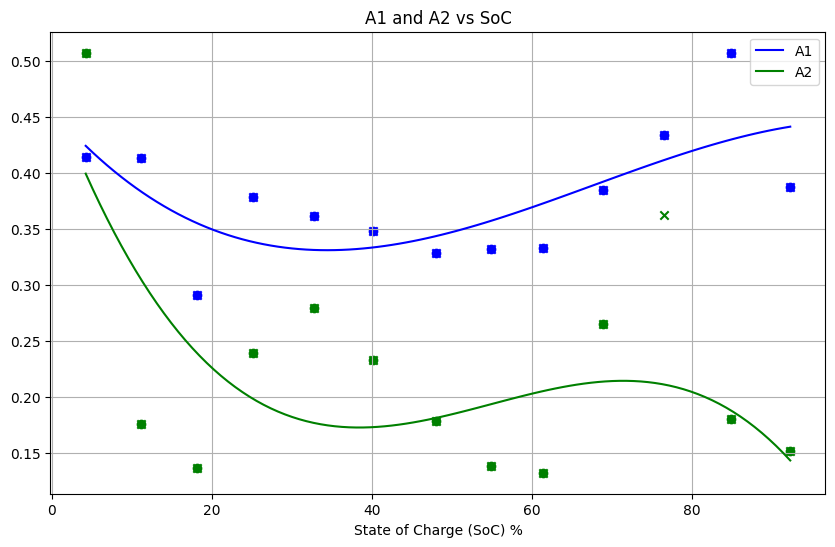

In [25]:
a1_cleaned = []
a1_soc = []
a2_cleaned = []
a2_soc = []

a1_index_to_drop = []
a2_index_to_drop = [2]

for i in range(len(fitted_params_list["SoC"])):
    if i not in a1_index_to_drop:
        a1_cleaned.append(fitted_params_list["A1"][i])
        a1_soc.append(fitted_params_list["SoC"][i])
    
    if i not in a2_index_to_drop:
        a2_cleaned.append(fitted_params_list["A2"][i])
        a2_soc.append(fitted_params_list["SoC"][i])
        
        
a_model = lambda x, a, b, c, d: a * (x - CENTER)**3 + b * (x - CENTER)**2 + c * (x - CENTER)**1 + d

a1_params, _ = curve_fit.curve_fit(a_model, a1_soc, a1_cleaned)
a2_params, _ = curve_fit.curve_fit(a_model, a2_soc, a2_cleaned)
print(f"A1 fit parameters: {a1_params}")
print(f"A2 fit parameters: {a2_params}")
print(f"R-squared for A1 fit: {r_squared(np.array(a1_soc), np.array(a1_cleaned), a_model, *a1_params):.4f}")
print(f"R-squared for A2 fit: {r_squared(np.array(a2_soc), np.array(a2_cleaned), a_model, *a2_params):.4f}")

soc_range = np.linspace(min(fitted_params_list["SoC"]), max(fitted_params_list["SoC"]), 100)
a1_fit = a_model(soc_range, *a1_params)
a2_fit = a_model(soc_range, *a2_params)

plt.figure(figsize=(10, 6))
plt.plot(soc_range, a1_fit, label='A1 Fit', color='blue')
plt.plot(soc_range, a2_fit, label='A2 Fit', color='green')
plt.scatter(a1_soc, a1_cleaned, label='A1 Data', color='blue', marker='o')
plt.scatter(a2_soc, a2_cleaned, label='A2 Data', color='green', marker='o')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["A1"], label='A1 Data', color='blue', marker='x')
plt.scatter(fitted_params_list["SoC"], fitted_params_list["A2"], label='A2 Data', color='green', marker='x')
plt.title('A1 and A2 vs SoC')
plt.xlabel('State of Charge (SoC) %')
plt.legend(['A1', 'A2'])
plt.grid()
plt.show()


In [26]:
# Chosen fitting
r_chosen_model = lambda x, a, b, c, d, e: a * (x - CENTER)**4 + b * (x - CENTER)**3 + c * (x - CENTER)**2 + d * (x - CENTER) + e
r0_final_params = r0_params
r1_final_params = r1_params
r2_final_params = r2_params
tau_chosen_model = lambda x, a, b, c: a * (x - CENTER)**4 + b * (x - CENTER)**2 + c
tau1_final_params = tau_1_params
tau2_final_params = tau_2_params
# C1 and C2 are calculated from R and Tau, so no separate fitting parameters
# But storing will only be for R and C

a_chosen_model = lambda x, a, b, c, d: a * (x - CENTER)**3 + b * (x - CENTER)**2 + c * (x - CENTER)**1 + d
a1_final_params = a1_params
a2_final_params = a2_params

In [27]:
factor = 3 # 3 dp
array_interval = factor + 2 # Additional 2 for 0 - 100% SoC

soc_array = np.linspace(0, 100, 10**array_interval + 1).round(factor)
r0_array = r_chosen_model(soc_array, *r0_final_params)
r1_array = r_chosen_model(soc_array, *r1_final_params)
r2_array = r_chosen_model(soc_array, *r2_final_params)
tau1_array = tau_chosen_model(soc_array, *tau1_final_params)
tau2_array = tau_chosen_model(soc_array, *tau2_final_params)
c1_array = tau1_array / r1_array
c2_array = tau2_array / r2_array
a1_array = a_chosen_model(soc_array, *a1_final_params)
a2_array = a_chosen_model(soc_array, *a2_final_params)

In [28]:
previous_ocv = pd.read_csv(ocv_soc_dict_file_name)

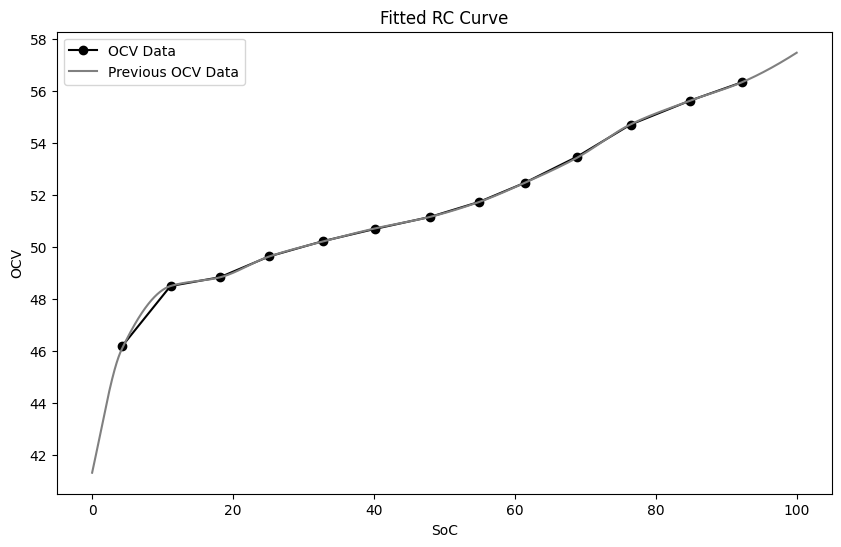

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(fitted_params_list["SoC"], fitted_params_list["OCV"], label='OCV Data', color='black', marker='o')
plt.plot(previous_ocv["SoC"], previous_ocv["OCV"], label='Previous OCV Data', color='gray')
plt.plot()
plt.xlabel('SoC')
plt.ylabel('OCV')
plt.title('Fitted RC Curve')
plt.legend()
plt.show()

In [30]:
# Save to CSV
output_df = pd.DataFrame({
    "SoC": soc_array,
    "R0": r0_array,
    "R1": r1_array,
    "R2": r2_array,
    "C1": c1_array,
    "C2": c2_array,
    'Tau1': tau1_array,
    'Tau2': tau2_array,
    "A1": a1_array,
    "A2": a2_array
})

output_df.to_csv(RC_values_file_name, index=False)
print(f"Saved fitted parameters to {RC_values_file_name}")

Saved fitted parameters to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\RC_values.csv


In [31]:
# Compile all battery data

rc_values_df = pd.read_csv(RC_values_file_name)
ocv_soc_dict_df = pd.read_csv(ocv_soc_dict_file_name)

if set(rc_values_df["SoC"]) != set(ocv_soc_dict_df["SoC"]):
    print("Warning: SoC values in RC values and OCV-SOC dictionary do not match.")
else:
    merged = pd.merge(rc_values_df, ocv_soc_dict_df, on="SoC", how="inner")
    merged = merged[["SoC", "OCV", "R0", "R1", "R2", "C1", "C2", "Tau1", "Tau2"]]
    print(merged.head())
    merged.to_csv(battery_state_file_name, index=False)
    print(f"Saved merged battery state data to {battery_state_file_name}")
    

     SoC        OCV        R0        R1        R2           C1            C2  \
0  0.000  41.299097  0.043064  0.017059  0.023024  4020.624984  22334.138950   
1  0.001  41.300333  0.043062  0.017059  0.023023  4020.551738  22336.088140   
2  0.002  41.301570  0.043061  0.017059  0.023022  4020.478501  22338.037406   
3  0.003  41.302807  0.043060  0.017059  0.023020  4020.405273  22339.986747   
4  0.004  41.304044  0.043059  0.017059  0.023019  4020.332054  22341.936165   

        Tau1        Tau2  
0  68.586913  514.227891  
1  68.585541  514.242101  
2  68.584170  514.256309  
3  68.582798  514.270515  
4  68.581427  514.284719  
Saved merged battery state data to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\battery_state.csv
